# ALDI Procurement Strategic Analysis

**Role perspective:** Senior Procurement Analyst  
**Data source:** `data_aldi.csv`  
**Objective:** Build a strategic, data-driven deliverable for the Purchasing Department.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Business style: clean charts with light grids
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Load data
file_path = r"c:\Users\pauli\Documents\code\kaggle\data_aldi.csv"
df = pd.read_csv(file_path)

# Clean percentage columns
pct_cols = [
    "Margin_Rate_%",
    "PDM_Value",
    "DN_%",
    "Penetration_Rate",
    "Promo_Weight_%",
]

for c in pct_cols:
    df[c] = (
        df[c].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Convert date column (format MM/YYYY)
df["Date"] = pd.to_datetime(df["Date"], format="%m/%Y", errors="coerce")

# Ensure numeric columns
num_cols = [
    "Sales_Value", "Sales_Volume", "VMH_Units", "Price_Index",
    "Promo_ROI", "Incremental_Uplift", "Purchase_Frequency", "SKU_Share_vs_PDM"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape:", df.shape)
display(df.head())

Shape: (828, 18)


,Date,Category,Segment,Brand,SKU_Name,Sales_Value,Sales_Volume,Margin_Rate_%,VMH_Units,PDM_Value,DN_%,Penetration_Rate,Purchase_Frequency,SKU_Share_vs_PDM,Price_Index,Promo_Weight_%,Incremental_Uplift,Promo_ROI
0,2024-05-01,Charcutería,MDD,La Tabla (ALDI),La Tabla (ALDI) Jamón Cocido 200g,25621.81,9111,24.3,35.1,14,99.6,17,8.0,0.92,93.0,5,1822,1.55
1,2024-05-01,Charcutería,MDD,La Tabla (ALDI),La Tabla (ALDI) Chorizo Ibérico 100g,22471.90,10984,21.2,32.2,9,100.0,27,1.8,0.84,88.0,24,2196,1.88
2,2024-05-01,Charcutería,MDD,La Tabla (ALDI),La Tabla (ALDI) Salchichón Extra,34629.04,15938,20.5,23.0,11,98.6,17,8.4,1.28,91.0,26,3187,1.73
3,2024-05-01,Charcutería,MDD,La Tabla (ALDI),La Tabla (ALDI) Fuet,40515.08,13868,21.0,21.2,21,99.4,34,5.5,0.94,92.0,27,2773,1.27
4,2024-05-01,Charcutería,Marque Nat.,Campofrío,Campofrío Jamón Cocido 200g,6099.58,2304,14.7,6.1,8,10.8,16,5.8,1.13,124.0,33,460,0.70


## Executive Summary

KPI globaux pour piloter la performance Achats :
- **Ventes totales**
- **Marge moyenne (%)**
- **Pénétration MDD vs Marque Nationale (MN)**

Total Sales: 9,915,182 €
Average Margin: 15.83%
MDD Penetration (sales share): 78.9%
MN Penetration (sales share): 21.1%


,Segment,Sales_Value,Sales_Share_%
0,MDD,7825531.28,78.924737
1,Marque Nat.,2089650.71,21.075263


C:\Users\pauli\AppData\Local\Temp\ipykernel_11300\2421796612.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x="Segment", y="Sales_Share_%", palette="Blues_r")


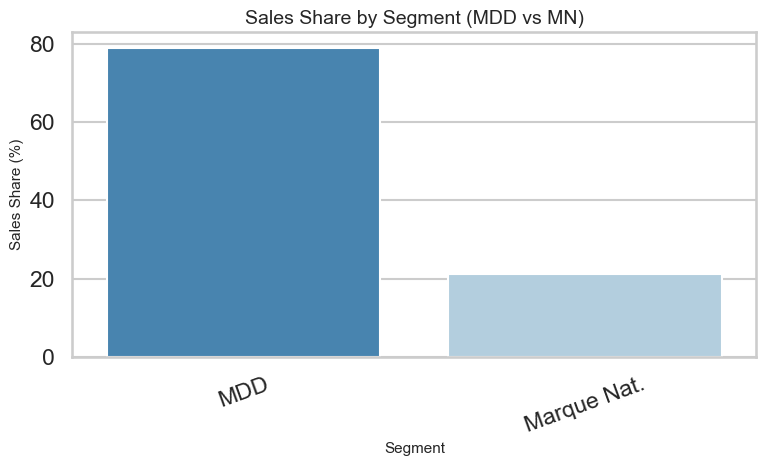

In [2]:
# --- Executive KPI ---
total_sales = df["Sales_Value"].sum()
avg_margin = df["Margin_Rate_%"].mean()

segment_sales = df.groupby("Segment", as_index=False)["Sales_Value"].sum()
segment_sales["Sales_Share_%"] = 100 * segment_sales["Sales_Value"] / segment_sales["Sales_Value"].sum()

mdd_share = segment_sales.loc[segment_sales["Segment"].str.contains("MDD", case=False, na=False), "Sales_Share_%"].sum()
mn_share = segment_sales.loc[~segment_sales["Segment"].str.contains("MDD", case=False, na=False), "Sales_Share_%"].sum()

print(f"Total Sales: {total_sales:,.0f} €")
print(f"Average Margin: {avg_margin:.2f}%")
print(f"MDD Penetration (sales share): {mdd_share:.1f}%")
print(f"MN Penetration (sales share): {mn_share:.1f}%")

display(segment_sales.sort_values("Sales_Value", ascending=False))

# Visual: MDD vs MN penetration
plt.figure(figsize=(8, 5))
plot_df = segment_sales.copy().sort_values("Sales_Share_%", ascending=False)
sns.barplot(data=plot_df, x="Segment", y="Sales_Share_%", palette="Blues_r")
plt.title("Sales Share by Segment (MDD vs MN)")
plt.xlabel("Segment")
plt.ylabel("Sales Share (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Analyse de l'Assortiment (Efficiency)

Objectif : mesurer l'efficacité de l'assortiment via la **VMH** et détecter les **Underperformers** (faible rotation + faible marge) pour rationalisation.

C:\Users\pauli\AppData\Local\Temp\ipykernel_11300\3006006708.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vmh_segment, x="Segment", y="VMH_Units", palette="viridis")


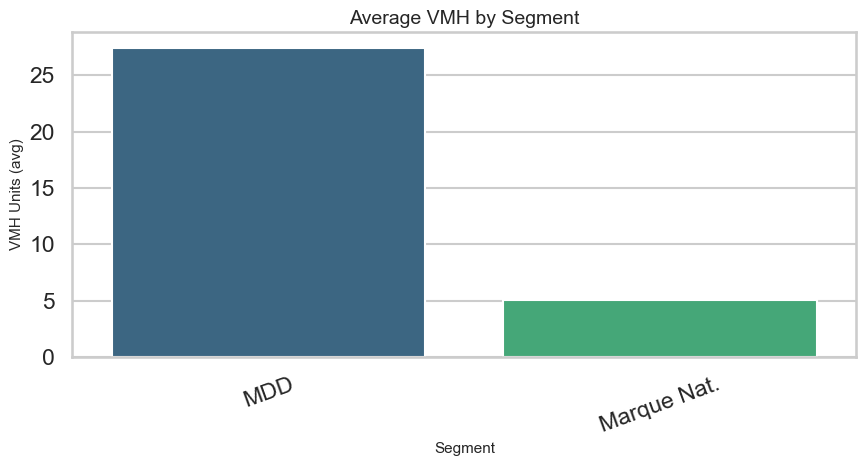

Underperformers identified: 314 SKUs


,Category,Brand,SKU_Name,Sales_Volume,Margin_Rate_%,VMH_Units
317,Lácteos,Danone,Danone Kefir,207,12.5,3.2
695,Charcutería,ElPozo,ElPozo Fuet,208,11.7,4.9
329,Charcutería,Campofrío,Campofrío Chorizo Ibérico 100g,210,12.6,7.9
178,Lácteos,Pascual,Pascual Bebida de Soja,214,10.0,2.9
597,Bebidas,Granini,Granini Smoothie Antiox 250ml,220,14.2,2.1
129,Bebidas,Granini,Granini Smoothie Antiox 250ml,225,11.2,4.1
43,Charcutería,Campofrío,Campofrío Fuet,230,11.5,5.6
184,Charcutería,Campofrío,Campofrío Jamón Cocido 200g,231,14.4,7.5
139,Lácteos,Danone,Danone Yogur Griego,243,13.3,3.3
671,Bebidas,Granini,Granini Limonada,250,12.0,4.6


In [3]:
# VMH by segment
vmh_segment = df.groupby("Segment", as_index=False)["VMH_Units"].mean().sort_values("VMH_Units", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=vmh_segment, x="Segment", y="VMH_Units", palette="viridis")
plt.title("Average VMH by Segment")
plt.xlabel("Segment")
plt.ylabel("VMH Units (avg)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Underperformers logic: below median on Sales_Volume and Margin_Rate_%
vol_threshold = df["Sales_Volume"].median()
margin_threshold = df["Margin_Rate_%"].median()

underperformers = df[
    (df["Sales_Volume"] < vol_threshold) &
    (df["Margin_Rate_%"] < margin_threshold)
].copy()

underperformers = underperformers.sort_values(["Sales_Volume", "Margin_Rate_%"], ascending=[True, True])

print(f"Underperformers identified: {len(underperformers)} SKUs")
display(underperformers[["Category", "Brand", "SKU_Name", "Sales_Volume", "Margin_Rate_%", "VMH_Units"]].head(20))

## Analyse de la Compétitivité Prix

Lecture métier : un **Price Index < 100** confirme le positionnement discounter d'ALDI.

,Category,Price_Index,Discounter_Position
2,Lácteos,107.876812,No
1,Charcutería,108.268116,No
0,Bebidas,108.891304,No


C:\Users\pauli\AppData\Local\Temp\ipykernel_11300\312664111.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_by_cat, x="Category", y="Price_Index", palette="coolwarm")


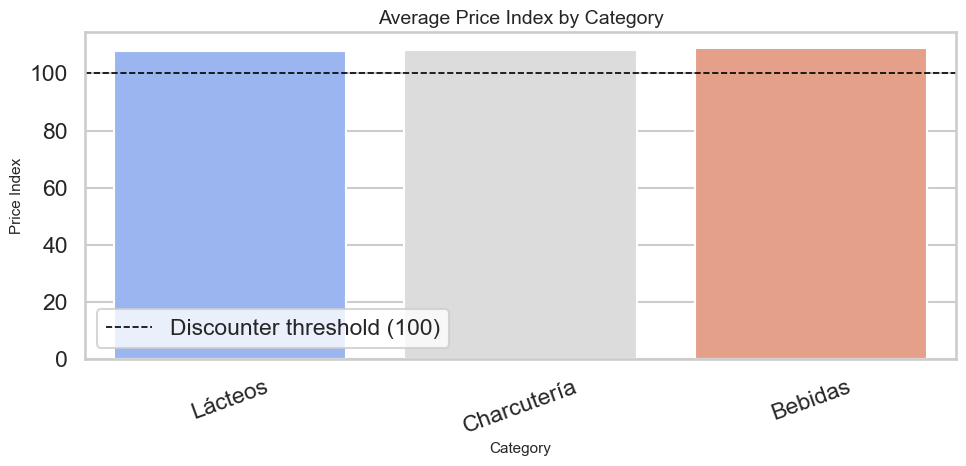

In [4]:
price_by_cat = df.groupby("Category", as_index=False)["Price_Index"].mean().sort_values("Price_Index")
price_by_cat["Discounter_Position"] = np.where(price_by_cat["Price_Index"] < 100, "Yes", "No")

display(price_by_cat)

plt.figure(figsize=(10, 5))
sns.barplot(data=price_by_cat, x="Category", y="Price_Index", palette="coolwarm")
plt.axhline(100, color="black", linestyle="--", linewidth=1.2, label="Discounter threshold (100)")
plt.title("Average Price Index by Category")
plt.xlabel("Category")
plt.ylabel("Price Index")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

## Analyse de la Performance Promotionnelle

Objectif : identifier les plans promo qui détruisent de la valeur (**Promo_ROI < 1**).

Promotions with ROI < 1: 375 SKUs


,Category,Brand,SKU_Name,Promo_Weight_%,Promo_ROI,Incremental_Uplift
4,Charcutería,Campofrío,Campofrío Jamón Cocido 200g,33,0.70,460
6,Charcutería,Campofrío,Campofrío Salchichón Extra,7,0.86,217
7,Charcutería,Campofrío,Campofrío Fuet,34,0.64,316
8,Charcutería,ElPozo,ElPozo Jamón Cocido 200g,33,0.77,353
9,Charcutería,ElPozo,ElPozo Chorizo Ibérico 100g,5,0.65,204
10,Charcutería,ElPozo,ElPozo Salchichón Extra,27,0.85,409
11,Charcutería,ElPozo,ElPozo Fuet,35,0.91,310
16,Bebidas,Don Simón,Don Simón Zumo Naranja 1L,5,0.74,508
17,Bebidas,Don Simón,Don Simón Smoothie Antiox 250ml,8,0.61,331
18,Bebidas,Don Simón,Don Simón Néctar Melocotón,15,0.85,201


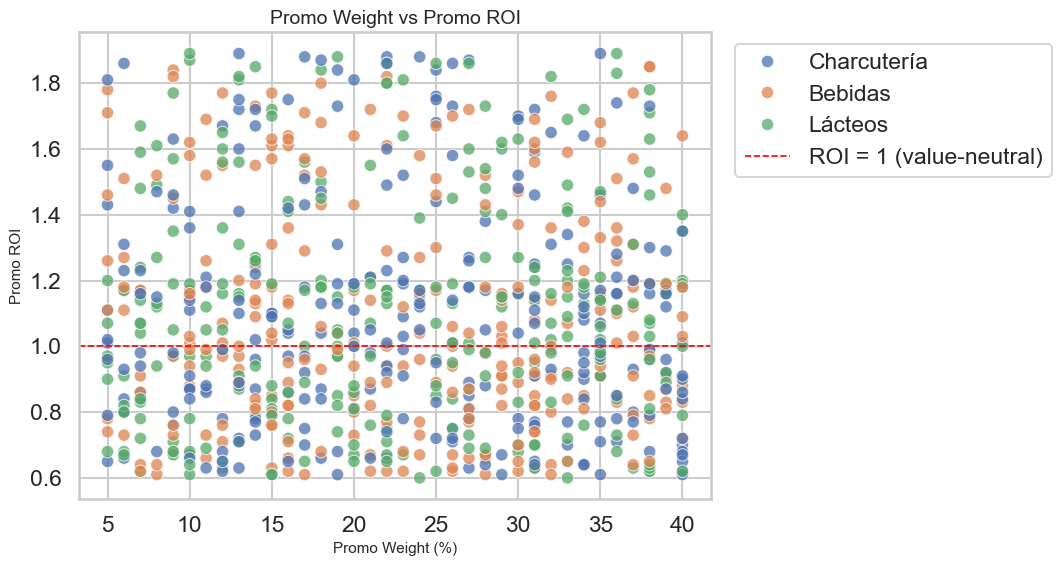

In [5]:
# Promotions destroying value
value_destroying = df[df["Promo_ROI"] < 1].copy()
print(f"Promotions with ROI < 1: {len(value_destroying)} SKUs")
display(value_destroying[["Category", "Brand", "SKU_Name", "Promo_Weight_%", "Promo_ROI", "Incremental_Uplift"]].head(25))

plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=df,
    x="Promo_Weight_%",
    y="Promo_ROI",
    hue="Category",
    alpha=0.75,
    s=80
)
plt.axhline(1, color="red", linestyle="--", linewidth=1.2, label="ROI = 1 (value-neutral)")
plt.title("Promo Weight vs Promo ROI")
plt.xlabel("Promo Weight (%)")
plt.ylabel("Promo ROI")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Recommandations Achats (FR + ES)

### 1) Rationaliser les SKU sous-performants
**FR :** Supprimer ou reformuler les SKU avec faible rotation et faible marge afin de libérer de la place linéaire pour les références à fort rendement.  
**ES :** Eliminar o reformular los SKU con baja rotación y bajo margen para liberar espacio en lineal para referencias de mayor rendimiento.

### 2) Renforcer le mix MDD sur les catégories avec Price Index favorable
**FR :** Dans les catégories où l'indice prix ALDI est déjà < 100, augmenter la part MDD pour renforcer l'avantage prix et la marge globale.  
**ES :** En categorías donde el índice de precio de ALDI ya es < 100, aumentar la cuota de MDD para reforzar la ventaja de precio y el margen global.

### 3) Recalibrer le plan promo orienté ROI
**FR :** Réduire l'intensité promo des SKU avec ROI < 1 et réallouer le budget vers les mécaniques/catégories à ROI > 1.2.  
**ES :** Reducir la intensidad promocional en SKU con ROI < 1 y reasignar el presupuesto a mecánicas/categorías con ROI > 1.2.